# Mouse head-direction data: statistics and model comparison

Characterizes the tuning curves of HD cells from the Peyrache et al. recordings and
compares them against the fitted generative model.

**Produces** Figures 1, 3, 4 and 5 and Supplementary Figure S13.

**Reads** `data/mouse_data/tc_data.npz`, `data/grid_search_results.npz` and
`data/analysis_results.npz`. With `REGENERATE_CACHES = True` it writes
`data/gamma_phi_info.npz` (the input to `python -m ring.gp_opt`) and rebuilds
`data/analysis_results.npz`.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False
REGENERATE_CACHES = False

# Standard library

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.stats import pearsonr

# Add custom package paths

# Local imports
from ring import style
from ring import fn
from ring import tc
from ring import gp_opt
from ring import plot
from ring import analysis

# Constants
TC_DATA_PATH = "../data/mouse_data/tc_data.npz"

## Load tuning curves

Keeps units that are HD-classified and non-degenerate, then rescales each tuning curve to unit mean, so that `Phi_m_data` matches the model's normalization convention. `Gamma_phi_data` is the resulting population covariance function, the fitting target for the grid search. The `np.savez("../data/gamma_phi_info.npz", ...)` here only runs when `REGENERATE_CACHES = True`. It is the only code that writes the file `ring/gp_opt.py` reads, so a from-scratch rebuild must run this cell with the flag on before running `python -m ring.gp_opt`.

In [2]:
"""
Load tuning curve data
"""

data = np.load(TC_DATA_PATH, "r")

opt_tcs = data['opt_tcs'].mean(1)
nz_mask = ~np.all(opt_tcs==0, axis=1)
hd_mask = data['hd_mask']
good_mask = nz_mask & hd_mask


Phi_m_data = opt_tcs[good_mask]
plain_tcs = data['plain_tcs'][good_mask]
opt_sigmas = data['opt_sigmas'][good_mask]
mouse_nums = data['mouse_nums'][good_mask]
mouse_names = data['mouse_names'][good_mask]
num_units = np.sum(good_mask)

"""
Phi_m = head-direction cell tuning curves w/ unity avg
"""
scalings = 1. / Phi_m_data.mean(axis=1)
Phi_m_data = Phi_m_data*scalings[:, None]

"""
Calc covariance
"""
Gamma_phi_data, Gamma_phi_data_ft = fn.calc_C(Phi_m_data)

"""
Save output so it can be loaded by the gp_opt.py
(uncomment if necessary)
"""
if REGENERATE_CACHES:
    np.savez("../data/gamma_phi_info.npz", Gamma_phi_data=Gamma_phi_data, Gamma_phi_data_ft=Gamma_phi_data_ft)

print("Phi_m.shape =", Phi_m_data.shape)

Phi_m.shape = (1533, 100)


## Tuning-curve statistics across mice

The cells in this block stay entirely on the data side. This one checks that the two cross-validated smoothing scales per unit agree; the cells below build the published data panels.

PearsonRResult(statistic=0.16023435754488818, pvalue=2.8005784800624424e-10)

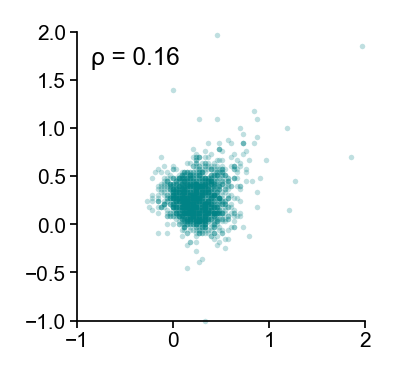

In [3]:
"""
Compare smoothing scales
"""
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.5), dpi=250)
plot.plot_log_sigma_scatter(ax, opt_sigmas)

pearsonr(np.log(opt_sigmas[:, 0]), np.log(opt_sigmas[:, 1]))

### Data tuning curves and mean/std profiles

Example tuning curves for the four mice with the most cells, alongside the population mean and standard deviation profiles. The drawing functions defined for these panels are reused by the `classical_attractor_vs_data` compose cell below.

Text(0.5, 0, '$\\theta$')

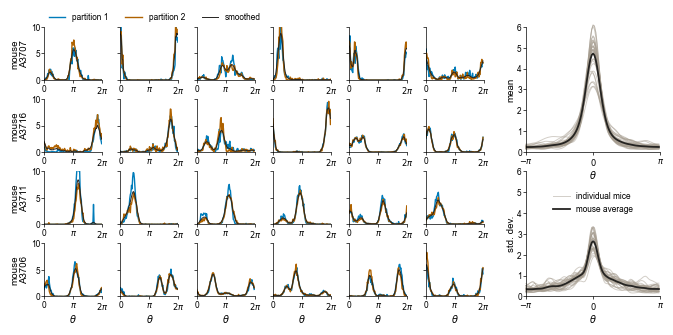

In [4]:
"""
Plot data tuning curves and mean/std profiles
"""


fig = plt.figure(figsize=(7, 3.1), dpi=100)
gs = plt.GridSpec(
    4, 9,
    width_ratios=[1]*6 + [0.1] + [1]*2,
    wspace=0.35,
    hspace=0.35,
    left=0.06,
    right=0.94,
    top=0.95,
    bottom=0.08
)

# Create tuning curve axes grid
curve_axes = np.empty((4, 6), dtype=object)
for i in range(4):
    for j in range(6):
        curve_axes[i, j] = fig.add_subplot(gs[i, j])

# Create profile axes
profile_axes = []
profile_axes.append(fig.add_subplot(gs[0:2, 7:])) # mean
profile_axes.append(fig.add_subplot(gs[2:4, 7:])) # std

# Select mice to plot
mouse_nums_to_plot = analysis.select_mice_by_cell_count(mouse_nums, 4)

# Compute mean and std profiles
mus, stds = analysis.compute_mean_and_std_profiles_for_all_mice(Phi_m_data, mouse_nums)

# Plot tuning curves
plot.plot_data_tuning_curves(
    curve_axes,
    mouse_nums_to_plot,
    mouse_nums,
    mouse_names,
    plain_tcs,
    scalings,
    Phi_m_data
)
curve_axes[0,0].legend(ncol=3, bbox_to_anchor=(-0.05, 0.95), loc='lower left')

# Plot profiles
plot.plot_mean_std_profiles(
    profile_axes[0],  # mean axis
    profile_axes[1],   # std axis
    mus,
    stds
)
profile_axes[1].set_facecolor((0,0,0,0))
profile_axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 0.6))

profile_axes[0].set_xlabel("$\\theta$")
profile_axes[1].set_xlabel("$\\theta$")



### Figure 3: centers of mass and subsampled covariances

Tests uniformity of preferred directions against a null, and shows how the population covariance approaches the translation-invariant ring form as more cells are included. `plt.savefig("../figures/circular_symmetry_in_data.pdf")` only runs when `SAVE_FIGURES = True`, so a normal run leaves the image in `figures/` alone.


Uniformity Test Results:
Number of mice: 31
Mice with p < 0.05 (uncorrected): 2
Mice with p < 0.05 (FDR-corrected): 0

P-value ranges:
Uncorrected: 4.4e-02 - 9.7e-01
FDR-corrected: 5.9e-01 - 9.7e-01


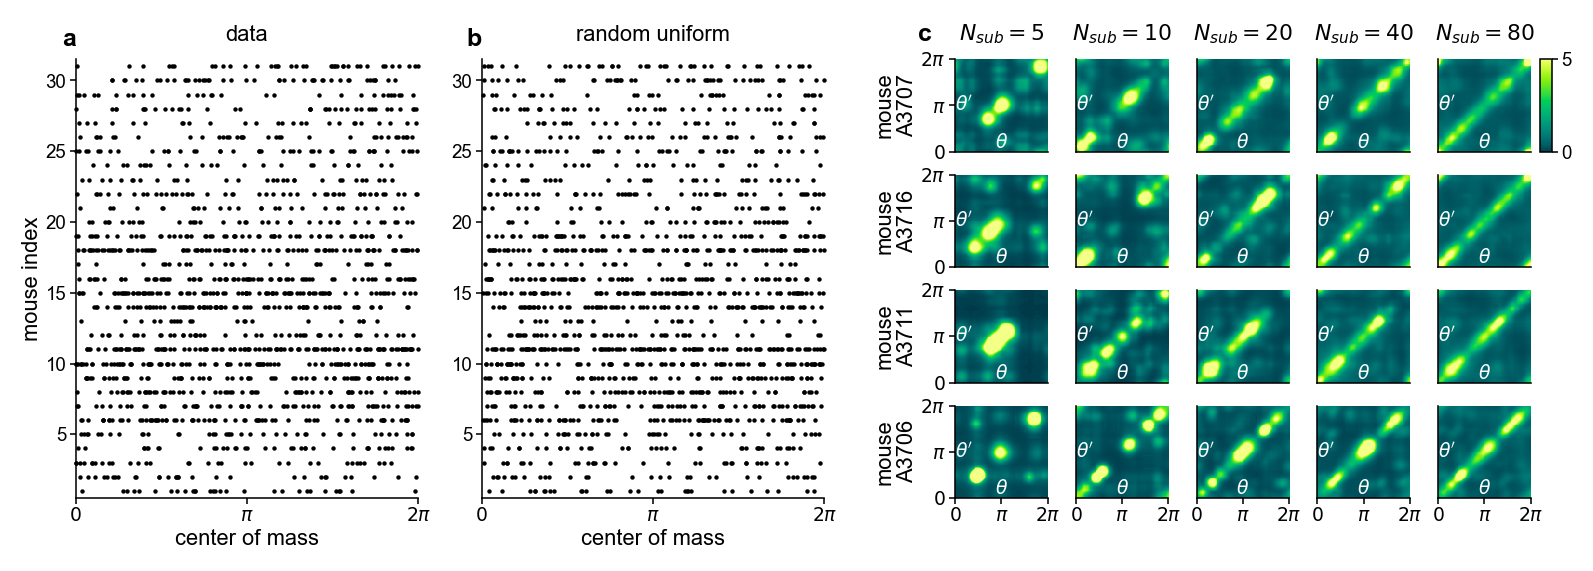

In [5]:
"""
Compose Fig. 3: per-mouse COM scatter (A, B) and subsampled covariance grid (C).
"""


# Standard double-column width; height is the standard short double-column
# height (style.SHORT_H), the reference height for the figure set. The
# covariance sub-axes in C are square (set_aspect(1)); at the reduced height they
# shrink, which would open horizontal gaps between them, so C's grid is packed
# tighter (small wspace/hspace) and its column trimmed, and the width reclaimed
# from that goes to widen A and B.
fig = plt.figure(figsize=(style.FULL_W, style.SHORT_H))

# Four columns: real COM, null COM, spacer, covariance grid. A and B are wider
# (1.35 vs the former 1.0) relative to the covariance block (2.3 vs 2.5).
gs = GridSpec(1, 4, width_ratios=[1.35, 1.35, 0.0, 2.3], figure=fig,
              # Shifted left as a block by 0.0053. The colorbar is added outside
              # the rightmost panel, so the DRAWN block reaches to 0.9605 while the
              # gridspec stops at 0.95; centring the drawn block, not the gridspec,
              # is what makes the two borders equal.
              left=0.0448, right=0.9448, bottom=0.1)

ax1 = fig.add_subplot(gs[0])  # Real COM
ax2 = fig.add_subplot(gs[1])  # Null COM
# gs[2] is an empty spacer

# Covariance grid, packed tight so the square cells sit close together.
gs_right = GridSpecFromSubplotSpec(4, 5, subplot_spec=gs[3], wspace=0.2, hspace=0.25)
axes_right = np.empty((4, 5), dtype=object)
for i in range(4):
    for j in range(5):
        axes_right[i, j] = fig.add_subplot(gs_right[i, j])

# Compute centers of mass
mouse_coms = analysis.compute_coms_for_all_mice(Phi_m_data, mouse_nums)

# Plot COM data
plot.plot_mouse_coms(ax1, mouse_coms, null=False, color='black')
plot.plot_mouse_coms(ax2, mouse_coms, null=True, color='black')
ax2.set_ylabel("")

# Plot covariance matrices
subsample_sizes = np.array([5, 10, 20, 40, 80])
im = plot.plot_covariance_grid(axes_right, mouse_nums, mouse_nums_to_plot,
                               mouse_names, Phi_m_data, subsample_sizes)

# Thin colorbar just past the right edge of the single top-right covariance panel,
# spanning only that panel's height (never a fat bar over all four rows). Placed
# manually rather than via style.attach_cbar because the helper's divider shrinks
# the aspect-locked host cell and breaks its alignment with the column below. The
# original bar carried no ticks, so none are added.
fig.canvas.draw()
_p = axes_right[0, 4].get_position()
cbar_ax = fig.add_axes([_p.x1 + 0.006, _p.y0, 0.007, _p.height])
_cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0, 5])
_cbar.ax.set_yticklabels(['0', '5'])
_cbar.ax.tick_params(labelsize=6, length=2, width=0.5, pad=1)
_cbar.outline.set_linewidth(0.5)

# Panel letters (house style: 8 pt bold, via style.panel_letter).
style.panel_letter(ax1, "a", x=0.0, y=1.02)
style.panel_letter(ax2, "b", x=0.0, y=1.02)
style.panel_letter(axes_right[0, 0], "c", x=-0.25, y=1.15)

if SAVE_FIGURES:
    plt.savefig("../figures/circular_symmetry_in_data.pdf", dpi=400)

# Analyze results
analysis.analyze_and_print_stats(mouse_coms)


### Supplementary Figure S13: normalized covariances and their eigenvectors

Same subsampling, but with the covariance normalized and centered, plus the leading eigenvectors for each mouse, showing the Fourier-like principal-component structure that a translation-invariant covariance produces. The cell-local `np.random.seed(42)` pins the `np.random.choice` subsampling, so the same neurons appear on every run.

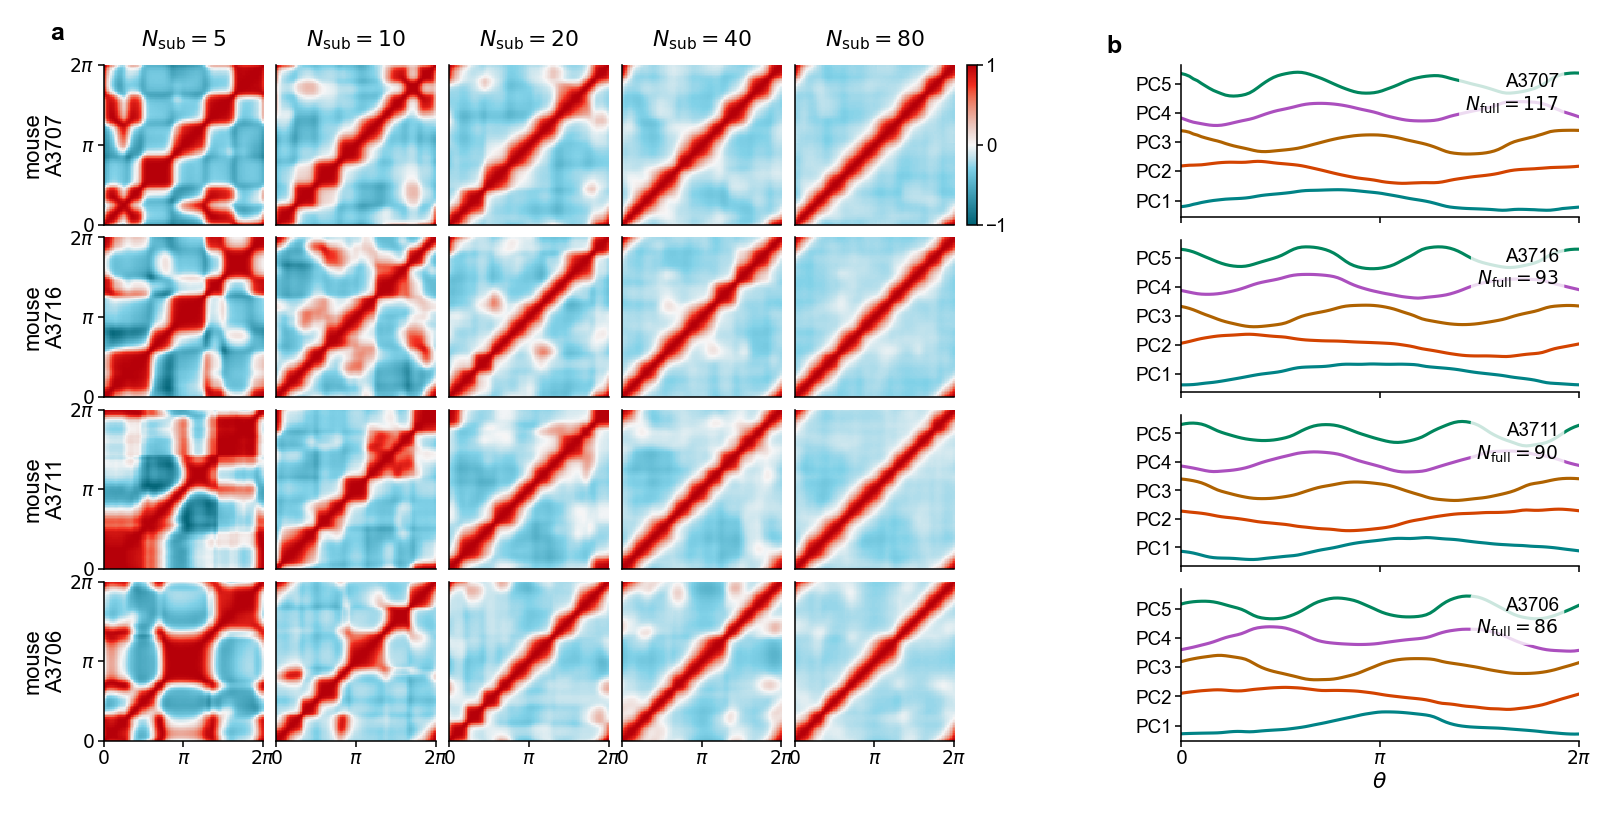

In [6]:
"""
Plot normalized centered covariance matrices and eigenvectors
"""

# Full-width supplement canvas. Panel A (4x5 covariance grid) on the left and
# panel B (4x1 eigenvector column) on the right are placed by explicit gridspecs
# with a real gap between them; the shared colorbar sits in that gap, spanning the
# full grid height, so its tick labels never collide with B's PC labels. Height is
# chosen so the aspect-locked (square) covariance cells fill their rows with
# minimal vertical gaps.
fig = plt.figure(figsize=(style.FULL_W, 3.9))

COV_L, COV_R = 0.055, 0.58     # covariance grid
EIG_L, EIG_R = 0.72, 0.965     # eigenvector column
TOP, BOT = 0.90, 0.13

# Main grid: covariance matrices on left (panel A)
gs_left = GridSpec(4, 5, figure=fig, left=COV_L, right=COV_R, top=TOP, bottom=BOT,
                   wspace=0.08, hspace=0.08)
axes_left = np.empty((4, 5), dtype=object)
for i in range(4):
    for j in range(5):
        axes_left[i, j] = fig.add_subplot(gs_left[i, j])

# Eigenvector column on the right (panel B)
gs_right = GridSpec(4, 1, figure=fig, left=EIG_L, right=EIG_R, top=TOP, bottom=BOT,
                    hspace=0.15)
axes_right = np.empty(4, dtype=object)
for i in range(4):
    axes_right[i] = fig.add_subplot(gs_right[i])

# Parameters
mouse_nums_to_plot = analysis.select_mice_by_cell_count(mouse_nums, 4)
subsample_sizes = np.array([5, 10, 20, 40, 80])
np.random.seed(42)  # Same random seed for consistency

# Plot normalized centered covariance matrices
vmax = 1.0  # Adjust as needed for normalized data

for i, mouse_num in enumerate(mouse_nums_to_plot):
    # Get tuning curves for mouse
    mouse_tcs = Phi_m_data[mouse_nums == mouse_num]
    num_tcs = mouse_tcs.shape[0]

    # Add mouse name for row
    mouse_name = mouse_names[mouse_nums == mouse_num][0]
    if i == 0:  # Only add column labels for first row
        for j, N_sub in enumerate(subsample_sizes):
            axes_left[i,j].set_title("$N_{\\text{sub}} = " + str(N_sub) + "$")

    # Add row label
    axes_left[i,0].set_ylabel(f'mouse\n{mouse_name}')

    for j, N_sub in enumerate(subsample_sizes):
        # Subsample and normalize/center
        sub_tcs = mouse_tcs[np.random.choice(np.arange(num_tcs), replace=False, size=N_sub)]
        sub_tcs_norm = (sub_tcs - sub_tcs.mean(axis=0, keepdims=True)) / sub_tcs.std(axis=0, keepdims=True)
        cov_norm = (sub_tcs_norm.T @ sub_tcs_norm) / N_sub

        im = axes_left[i,j].imshow(cov_norm, extent=[0,2*np.pi, 0,2*np.pi], origin='lower',
                                  vmin=-vmax, vmax=vmax, cmap=style.DIVERGING_CMAP, interpolation="nearest")

        # Format axes
        if i == len(mouse_nums_to_plot)-1:
            axes_left[i,j].set_xticks([0,np.pi,2*np.pi])
            axes_left[i,j].set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
        else:
            axes_left[i,j].set_xticks([])

        if j == 0:
            axes_left[i,j].set_yticks([0,np.pi,2*np.pi])
            axes_left[i,j].set_yticklabels(["$0$", "$\\pi$", "$2\\pi$"])
        else:
            axes_left[i,j].set_yticks([])

        axes_left[i,j].set_aspect(1.)

# Plot eigenvectors for all 4 mice
colors = style.CATEGORICAL
offset_scale = 0.4

for i, mouse_num in enumerate(mouse_nums_to_plot):
    # Get and process data for this mouse
    Phi_m_session = Phi_m_data[mouse_nums == mouse_num]
    num_neurons = len(Phi_m_session)
    mouse_name = mouse_names[mouse_nums == mouse_num][0]

    # Normalize and center
    Phi_m_session_ctd = (Phi_m_session - Phi_m_session.mean(axis=0, keepdims=True)) / Phi_m_session.std(axis=0, keepdims=True)
    cov = (Phi_m_session_ctd.T @ Phi_m_session_ctd) / len(Phi_m_session_ctd)

    # Compute eigendecomposition
    w, V = np.linalg.eigh(cov)
    w, V = w[::-1], V[:, ::-1]  # Sort in descending order

    # Plot first 5 eigenvectors with vertical offset
    theta_plot = np.linspace(0, 2*np.pi, V.shape[0])

    for k in range(5):
        axes_right[i].plot(theta_plot, V[:, k] + offset_scale * k,
                          color=colors[k], linewidth=1.0)

    # Format axes
    axes_right[i].set_xlim(0, 2*np.pi)
    axes_right[i].set_xticks([0, np.pi, 2*np.pi])

    if i == len(mouse_nums_to_plot)-1:  # Bottom subplot
        axes_right[i].set_xticklabels(['$0$', '$\\pi$', '$2\\pi$'])
        axes_right[i].set_xlabel('$\\theta$')
    else:
        axes_right[i].set_xticklabels([])

    # Add neuron count and mouse name
    axes_right[i].text(0.95, 0.95, mouse_name + "\n$N_{\\text{full}}="+str(num_neurons)+"$",
                      transform=axes_right[i].transAxes, fontsize=6,
                      va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    axes_right[i].set_yticks(offset_scale * np.arange(5))
    axes_right[i].set_yticklabels(["PC{}".format(k+1) for k in range(5)])

# Thin colorbar just past the right edge of the single top-right covariance panel,
# spanning only that panel's height (never a fat bar over all four rows). Placed
# manually rather than via style.attach_cbar because the helper's divider shrinks
# the aspect-locked host cell and breaks its alignment with the column below.
fig.canvas.draw()
_p = axes_left[0, 4].get_position()
cbar_ax = fig.add_axes([_p.x1 + 0.008, _p.y0, 0.006, _p.height])
_cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
_cbar.outline.set_linewidth(0.5)

# Add panel labels
axes_left[0,0].text(-0.25, 1.125, "a", transform=axes_left[0,0].transAxes,
                   fontsize=8, fontweight='bold', va='bottom', ha='right')
axes_right[0].text(-0.15, 1.05, "b", transform=axes_right[0].transAxes,
                  fontsize=8, fontweight='bold', va='bottom', ha='right')

if SAVE_FIGURES:
    plt.savefig("../figures/normalized_covariance_eigenvectors.png", dpi=400, bbox_inches='tight')
plt.show()

## Generative model: load grid-search results

The (scale, bias, beta) grid search itself lives in `ring/gp_opt.py:run_grid_search` (seeded 42) and is run separately with `python -m ring.gp_opt`; this cell just loads `grid_search_results.npz` and re-derives the optimum from the loss grid as a cross-check against the saved `best_params`.

In [7]:
"""
Plot optimization results
"""

import os

INPUT_RESULTS_FILE = '../data/grid_search_results.npz'

if not os.path.exists(INPUT_RESULTS_FILE):
    raise FileNotFoundError(
        f"{INPUT_RESULTS_FILE} not found. It ships with the Zenodo download. "
        "To rebuild it from scratch instead, run the cells above first (they "
        "write gamma_phi_info.npz), then run 'python -m ring.gp_opt' (about "
        "13 minutes), then rerun the notebook from the top."
    )

data = np.load(INPUT_RESULTS_FILE, allow_pickle=True)

# Load basic data
scale_vals = data['scale_vals']
bias_vals = data['bias_vals']
beta_vals = data['beta_vals']
loss_vals = data['loss_vals']
bounds = data['bounds']
opt_params = data['best_params']

# Calculate optimal values
min_losses = loss_vals.min(axis=(1,2))
opt_scale_idx = np.argmin(min_losses)
opt_scale = scale_vals[opt_scale_idx]

# Get loss slice at optimal scale
loss_slice = loss_vals[opt_scale_idx]
min_idx = np.unravel_index(np.argmin(loss_slice), loss_slice.shape)

# Get optimal parameters
opt_bias = bias_vals[min_idx[0]]
opt_beta = beta_vals[min_idx[1]]
min_loss = loss_vals[opt_scale_idx, min_idx[0], min_idx[1]]

# These should agree!
print(opt_params) # dict saved from gp_opt
print(opt_scale, opt_bias, opt_beta) #opt computed here
opt_params = (opt_scale, opt_bias, opt_beta)


{'scale': 1.4210526315789473, 'bias': 1.7306896551724138, 'beta': 2.765862068965517, 'loss': 0.008898164406421858}
1.4210526315789473 1.7306896551724138 2.765862068965517


## Model/data comparison statistics (writes `analysis_results.npz`)

Samples 100k tuning curves from the fitted model and compares peak counts, peak values, symmetry and information against the data, writing `../data/analysis_results.npz`. `run_model_comp_analysis()` only runs when `REGENERATE_CACHES = True`, since the cached results are what Fig 5 is drawn from. Rebuilding them redraws the model samples, so the peak-count panels shift slightly.

In [8]:
"""
Run model/data comparison
"""

# Seed before gp_opt.gen_Phi_m (uses unseeded numpy RNG in sample_z's numpy branch)
np.random.seed(42)

def run_model_comp_analysis():
    # Generate data 
    Phi_m = gp_opt.gen_Phi_m(*opt_params, N_samples=100000, N_theta=100)
    Phi_m = Phi_m / Phi_m.mean(1, keepdims=True)
    
    # Run analysis
    results = analysis.analyze_tuning_curves(Phi_m_data, Phi_m)
    
    # Save results
    analysis.save_analysis_results(results, '../data/analysis_results.npz')

if REGENERATE_CACHES:
    run_model_comp_analysis()

## Model vs. data

The cells in this block build the three panel groups that the `model_vs_data` compose cell assembles. Each cell sets `np.random.seed(42)` at the top because `gp_opt.gen_Phi_m` and `tc.sample_tcs` draw from the global numpy RNG.

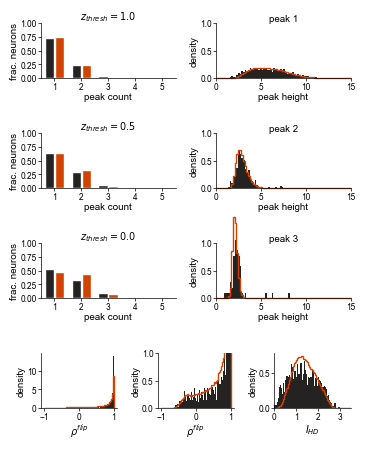

In [9]:
"""
Plot data/model comparison
"""


# Load results
results = analysis.load_analysis_results('../data/analysis_results.npz')

fig, axes = plt.subplot_mosaic("""
AAABBB
CCCDDD
EEEFFF
GGHHII
""", figsize=(4, 5), dpi=100)
plt.subplots_adjust(wspace=2.25, hspace=1)

# Create plots
z_thresholds = [1.0, 0.5, 0.0]

# Peak counts
for ax, (data_counts, model_counts), z_thresh in zip([axes['A'], axes['C'], axes['E']], results['peak_counts'], z_thresholds):
    plot.plot_peak_count_comparison(ax, data_counts, model_counts)
    ax.set_title("$z_{thresh}"+" = {}$".format(z_thresh), pad=0)

# Peak values
data_peaks, model_peaks = results['peak_values']
for i, ax in enumerate([axes['B'], axes['D'], axes['F']]):
    plot.plot_peak_value_histograms(ax, data_peaks[:, i], model_peaks[:, i])
    ax.set_title("peak {}".format(i+1), pad=0)

# Symmetry
data_sym, model_sym = results['symmetry']
plot.plot_symmetry_histogram(axes['G'], data_sym, model_sym)
plot.plot_symmetry_histogram(axes['H'], data_sym, model_sym, ylim=(0, 1))

# Information
data_info, model_info = results['information']
plot.plot_information_histogram(axes['I'], data_info, model_info)




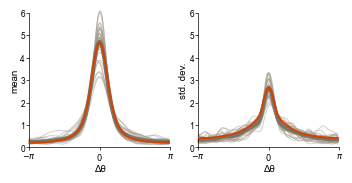

In [10]:
"""
Plot gen. model predictions atop data
"""

# Seed before plot_mean_std_profiles (calls gp_opt.gen_Phi_m indirectly)
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(4, 1.75), dpi=100)
plot.plot_mean_std_profiles(axes[0], axes[1], mus, stds, opt_params=opt_params)



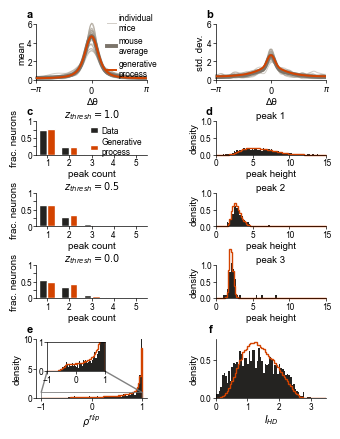

In [11]:
"""
Compose Fig. 5 in full: generative model vs. mouse HD data, single-column.

Every panel is drawn and composed in code. All panels reuse the same drawing functions as the
standalone panel cells above; only the arrangement changes, reflowed into a
compact single column that reads top to bottom:
  A,B  mean / std center-of-mass-aligned profiles  (plot.plot_mean_std_profiles)
  C    peak-count distributions, 3 z-thresholds     (plot.plot_peak_count_comparison)
  D    peak-height distributions, peaks 1-3          (plot.plot_peak_value_histograms)
  E    flip-symmetry rho_flip, full distribution with the zoomed tail drawn as an
       inset (upper-left), with zoom-indicator lines marking the magnified band
                                                     (plot.plot_symmetry_histogram)
  F    head-direction information I_HD               (plot.plot_information_histogram)
E and F are equal-width (both a single outer column); the zoomed tail of E's
distribution is an inset inside E. The model curves in A/B
come from gp_opt.gen_Phi_m, which draws from the global numpy RNG, so
np.random.seed(42) is set first.
"""


# Model/data comparison statistics (same cache as the SVG cells above).
results = analysis.load_analysis_results('../data/analysis_results.npz')

# Single column (style.COL_W). top is pulled down to 0.90 to leave a strip
# above row 1 for panel A's legend, which now sits above the profile curves.
FIG_W, FIG_H = style.COL_W, 4.62
_MM = FIG_W * 25.4            # printed canvas width, 89 mm

# Equal left/right border whitespace, measured from the canvas edge to the
# outermost SPINE (the axes box, NOT the ink bounding box: the y labels overhang
# on the left and have no counterpart on the right, so equalizing ink would push
# the block off centre). _PAD is therefore the same on both sides, and it is set
# to the smallest value that still fits the widest left-hand label group, which
# is panel C's y label plus its tick labels, with a little clearance left over.
_LABEL_MM = 6.65              # panel C: y label + tick labels, spine to ink
_CLEAR_MM = 1.00              # white between that ink and the canvas edge
_PAD = (_LABEL_MM + _CLEAR_MM) / _MM
_WSPACE = 0.62

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)

outer = fig.add_gridspec(
    3, 2,
    height_ratios=[1.0, 3.15, 1.05],
    hspace=0.42, wspace=_WSPACE,
    left=_PAD, right=1 - _PAD, top=0.90, bottom=0.09,
)

# --- Row 1: A (mean profile) | B (std profile) ---
ax_A = fig.add_subplot(outer[0, 0])
ax_B = fig.add_subplot(outer[0, 1])
np.random.seed(42)  # Seed before gp_opt.gen_Phi_m (unseeded numpy RNG)
plot.plot_mean_std_profiles(ax_A, ax_B, mus, stds, opt_params=opt_params)
# Legend stacked in Panel A's upper-right corner. The mean profile decays toward
# the tails, leaving that corner empty; the block may overflow past A's top-right
# (no top/right spines there). Single column; "generative process" wraps to two
# lines to keep the block narrow.
_hA, _lA = ax_A.get_legend_handles_labels()
_ord = ['individual mice', 'mouse average', 'generative process']
_disp = {'individual mice': 'individual\nmice',
         'mouse average': 'mouse\naverage',
         'generative process': 'generative\nprocess'}
_hd = dict(zip(_lA, _hA))
_hA = [_hd[l] for l in _ord]
_lA = [_disp[l] for l in _ord]
# Two-line labels keep the block narrow so its left edge stays right of the
# central peak; anchored at A's upper-right, allowed to overflow slightly above.
ax_A.legend(_hA, _lA, loc='upper right', bbox_to_anchor=(1.15, 1.30),
            ncol=1, fontsize=6, frameon=False, handlelength=1.0,
            handletextpad=0.4, labelspacing=0.45, borderpad=0.2)

# --- Row 2 left: C, three peak-count bar charts stacked (z_thresh 1.0/0.5/0.0) ---
# The inner hspace is larger than the outer row gap because the panels are now
# short, so the gap must still leave absolute room for each panel's x-label and
# the title of the panel below it.
gsC = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[1, 0], hspace=1.15)
z_thresholds = [1.0, 0.5, 0.0]
axesC = [fig.add_subplot(gsC[i]) for i in range(3)]
for k, (ax, (data_counts, model_counts), z_thresh) in enumerate(
        zip(axesC, results['peak_counts'], z_thresholds)):
    plot.plot_peak_count_comparison(ax, data_counts, model_counts)
    # Label 0, 0.5, 1 only. All five tick MARKS stay; dropping the two
    # four-character labels uncrowds an 8.5 mm tall panel and narrows the
    # figure's widest left-hand label group by 1.2 mm, which is width the whole
    # figure gets back once the two border pads are equalized.
    ax.set_yticklabels(['0', '', '0.5', '', '1'])
    ax.set_title("$z_{thresh}" + " = {}$".format(z_thresh), pad=2)
    if k == 0:
        ax.legend(loc='upper right', fontsize=6, handlelength=0.9,
                  handletextpad=0.4, borderaxespad=0.2, labelspacing=0.25)

# --- Row 2 right: D, three peak-height histograms stacked (peaks 1/2/3) ---
gsD = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[1, 1], hspace=1.15)
data_peaks, model_peaks = results['peak_values']
axesD = [fig.add_subplot(gsD[i]) for i in range(3)]
for i, ax in enumerate(axesD):
    plot.plot_peak_value_histograms(ax, data_peaks[:, i], model_peaks[:, i])
    ax.set_title("peak {}".format(i + 1), pad=2)

# --- Row 3 left: E, flip-symmetry full distribution with zoomed-tail inset ---
# E is a single panel spanning the same width as F. The full rho_flip distribution
# spikes near +1; the zoomed tail (ylim 0..1) is drawn as an inset in the upper
# left, where the full distribution sits at ~0 so the inset covers no ink.
data_sym, model_sym = results['symmetry']
ax_E = fig.add_subplot(outer[2, 0])
plot.plot_symmetry_histogram(ax_E, data_sym, model_sym)
ax_E.set_ylim(0, 10)   # main axis clips the tall grey data spike; inset zooms 0..1
ax_E_inset = ax_E.inset_axes([0.10, 0.46, 0.52, 0.50])
plot.plot_symmetry_histogram(ax_E_inset, data_sym, model_sym, ylim=(0, 1))
ax_E_inset.set_xlabel('')
ax_E_inset.set_ylabel('')
ax_E_inset.tick_params(labelsize=6, length=2, pad=1)
ax_E_inset.set_xlim(-1, 1)
ax_E_inset.set_xticks([-1, 0, 1])
ax_E_inset.set_yticks([0, 1])
# Draw the inset as a full box (all four spines), overriding the top/right
# spine removal done inside plot_symmetry_histogram.
for _sp in ax_E_inset.spines.values():
    _sp.set_visible(True)
    _sp.set_linewidth(0.5)
# Zoom-indicator: the highlight box marks the magnified region (all x, y in 0..10)
# on the main axes. Keep the two connectors leaving the inset's BOTTOM corners
# (indices 0 and 2 = lower-left, lower-right of the LL, UL, LR, UR tuple) and
# re-point their far ends to the highlight box's TOP corners, so each line runs
# from an inset bottom corner up to a highlight-box top corner.
_rect, _conns = ax_E.indicate_inset_zoom(ax_E_inset, edgecolor='0.45',
                                         lw=0.6, alpha=0.9)
_x0, _x1 = ax_E_inset.get_xlim()
_y0, _y1 = ax_E_inset.get_ylim()
_conns[0].xy2 = (_x0, _y1)   # inset lower-left  -> highlight-box top-left
_conns[2].xy2 = (_x1, _y1)   # inset lower-right -> highlight-box top-right
for _i, _c in enumerate(_conns):
    _c.set_visible(_i in (0, 2))

# --- Row 3 right: F, head-direction information ---
ax_F = fig.add_subplot(outer[2, 1])
data_info, model_info = results['information']
plot.plot_information_histogram(ax_F, data_info, model_info)

# --- panel letters ---
# House style (8 pt bold) via style.panel_letter. Each letter sits just above its
# panel's y tick labels: its right edge _LTR_DX_MM left of the panel's left
# spine, its baseline _LTR_DY_MM above the top spine, which clears the topmost
# tick label and stays clear of the y label further out. Both offsets are in mm
# on the page, so panels of different sizes get the same visual placement. This
# is the convention Fig 7 uses. Anchoring the letters far outside the axes box,
# rather than just clear of the tick labels, would force an oversized left
# pad.
_LTR_DX_MM, _LTR_DY_MM = 0.75, 1.20
for _ax, _s in [(ax_A, 'a'), (ax_B, 'b'), (axesC[0], 'c'),
                (axesD[0], 'd'), (ax_E, 'e'), (ax_F, 'f')]:
    _bb = _ax.get_position()
    style.panel_letter(_ax, _s,
                       x=-_LTR_DX_MM / (_bb.width * _MM),
                       y=1 + _LTR_DY_MM / (_bb.height * FIG_H * 25.4))

if SAVE_FIGURES:
    plt.savefig("../figures/model_vs_data.pdf")


In [12]:
"""
Get Gamma_phi_opt with optimial params (i.e., the fitted model covariance fn; this was the output of the optimization)
"""

Gamma_phi_opt, _ = gp_opt.compute_cov_from_params(params=opt_params, N_samples=100000, N_theta=100, device=None)


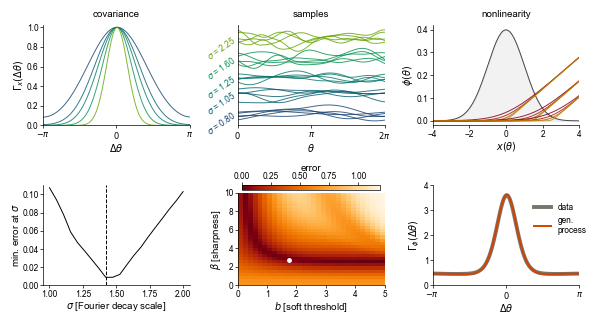

In [13]:
"""
Plot optimization fig
"""

# Seed before plot_pre_examples (calls tc.sample_tcs which uses unseeded numpy RNG)
np.random.seed(42)


fig, axes = plt.subplots(2, 3, figsize=(6, 3.25), dpi=100) #, width_ratios=[1, 1, 0.2, 1])

plot.plot_cov_examples(axes[0, 0])
plot.plot_pre_examples(axes[0, 1])
plot.plot_nonlin_examples(axes[0, 2])

plot.plot_loss_vs_scale(axes[1,0], scale_vals, min_losses, opt_scale)
plot.plot_loss_landscape(axes[1,1], loss_slice, bias_vals, beta_vals,  opt_bias, opt_beta)
plot.plot_covariance_comparison(axes[1, 2], Gamma_phi_data, Gamma_phi_opt)
plt.tight_layout()


## Schematic panels for Figure 4

The cells below draw the illustrative panels of Figure 4: model tuning-curve samples, an idealized Gaussian `J(θ−θ′)`, and a cartoon bump-tuning example. The compose cell below draws the tuning-curve sample grid directly into Fig 4.

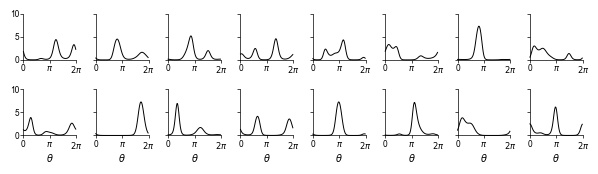

In [14]:
"""
Plot samples from gen. process
"""

fig, axes = plt.subplots(2, 8, figsize=(6, 1.75), dpi=100)
plot.plot_model_tuning_curves(axes, opt_params)
plt.tight_layout()


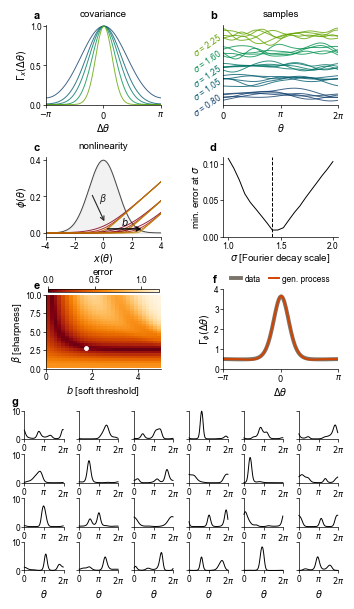

In [15]:
"""
Compose Fig. 4 in full: generative model fitting + tuning-curve samples,
reflowed into a single column (style.COL_W).

Composes the A-F fitting grid and the tuning-curve sample grid into one
code-composed figure. Every panel reuses the same drawing functions as the
panel cells above; only the arrangement changes into a single column:
  A  wrap-Gaussian covariance functions        (plot.plot_cov_examples)
  B  pre-nonlinearity GP samples               (plot.plot_pre_examples)
  C  softplus nonlinearity family              (plot.plot_nonlin_examples)
  D  fitting error vs sigma                     (plot.plot_loss_vs_scale)
  E  (bias, beta) error landscape              (plot.plot_loss_landscape)
  F  data vs gen-process two-point covariance  (plot.plot_covariance_comparison)
  G  random model tuning-curve samples, 4x6    (plot.plot_model_tuning_curves)

A-F are a 3-row x 2-col block, since a single column is too narrow for the old
2x3. G is a 4-row x 6-col MINI grid whose per-panel aspect echoes Fig 1's
real-data tuning-curve grid, drawn smaller because these are model samples.
plot_pre_examples and plot_model_tuning_curves draw from the global numpy RNG,
so np.random.seed(42) is set before each.
"""


FIG_W = style.COL_W
_MM = FIG_W * 25.4            # printed canvas width, 89 mm

# Equal left/right border whitespace, measured from the canvas edge to the
# outermost SPINE (the axes box, NOT the ink bounding box). The outer envelope
# on both sides is the G block, so _PAD is G's pad; the A-F block is inset by
# more because its y labels are wider. Both label groups then end on the same
# left ink line, _CLEAR_MM from the canvas edge.
_G_LABEL_MM = 3.65            # G, left column: panel letter, spine to ink
                              # (3.45 for its y tick labels; the letter is wider)
_AF_LABEL_MM = 9.10           # A-F, left column: widest y label + tick labels
_CLEAR_MM = 1.00              # white between that ink and the canvas edge
_PAD = (_G_LABEL_MM + _CLEAR_MM) / _MM

# --- top block A-F: 3 rows x 2 cols -----------------------------------------
# A-F extend right to G_R so the A-F block's right edge aligns with the right edge
# of G's rightmost column. Panel B's sigma labels were moved to the LEFT of its
# left spine (in plot_pre_examples), which freed this width.
TOP_L, TOP_R = (_AF_LABEL_MM + _CLEAR_MM) / _MM, 1 - _PAD
TOP_WSPACE = 0.54
TOP_MARGIN_IN = 0.30          # above row-0 titles
PANEL_H_IN = 0.80            # per-panel axes-box height
ROW_GAP_IN = 0.52            # holds x-labels and E's top colorbar

# --- bottom block G: 4 rows x 6 cols, per-panel aspect matched to Fig 1 grid --
G_L, G_R = _PAD, 1 - _PAD
G_WSPACE, G_HSPACE = 0.40, 0.55
G_ASPECT = 1.386             # w/h of Fig 1's tuning-curve panels
MID_GAP_IN = 0.42           # between the A-F block and the sample grid
BOT_MARGIN_IN = 0.30        # below G's theta labels

avail_g = (G_R - G_L) * FIG_W
w_g = avail_g / (6 + 5 * G_WSPACE)
h_g = w_g / G_ASPECT
G_BLOCK_H_IN = h_g * (4 + 3 * G_HSPACE)

AF_BLOCK_H_IN = 3 * PANEL_H_IN + 2 * ROW_GAP_IN
FIG_H = (TOP_MARGIN_IN + AF_BLOCK_H_IN + MID_GAP_IN
         + G_BLOCK_H_IN + BOT_MARGIN_IN)

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)

top_top = 1.0 - TOP_MARGIN_IN / FIG_H
top_bot = (BOT_MARGIN_IN + G_BLOCK_H_IN + MID_GAP_IN) / FIG_H
top = fig.add_gridspec(3, 2, left=TOP_L, right=TOP_R,
                       top=top_top, bottom=top_bot,
                       wspace=TOP_WSPACE, hspace=ROW_GAP_IN / PANEL_H_IN)
axAF = np.empty((3, 2), dtype=object)
for i in range(3):
    for j in range(2):
        axAF[i, j] = fig.add_subplot(top[i, j])

np.random.seed(42)  # Seed before plot_pre_examples (tc.sample_tcs uses numpy RNG)
plot.plot_cov_examples(axAF[0, 0])
plot.plot_pre_examples(axAF[0, 1])
plot.plot_nonlin_examples(axAF[1, 0])

# Panel C annotations (DRAFT placement -- flag for David to confirm): increasing
# the softplus steepness beta makes the input-output curve kinkier (sharper
# corner), while increasing the bias b shifts the activation threshold rightward.
_axC = axAF[1, 0]
_axC.annotate('', xy=(0.15, 0.05), xytext=(-0.85, 0.22),
              arrowprops=dict(arrowstyle='->', color='0.15', lw=0.8))
_axC.text(-0.28, 0.15, r'$\beta$', color='0.15', size=7, ha='left', va='bottom')
_axC.annotate('', xy=(2.85, 0.022), xytext=(0.1, 0.022),
              arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
_axC.text(1.5, 0.031, r'$b$', color='black', size=7, ha='center', va='bottom')

plot.plot_loss_vs_scale(axAF[1, 1], scale_vals, min_losses, opt_scale)
plot.plot_loss_landscape(axAF[2, 0], loss_slice, bias_vals, beta_vals, opt_bias, opt_beta)
plot.plot_covariance_comparison(axAF[2, 1], Gamma_phi_data, Gamma_phi_opt)

# Panel F legend: two entries side by side just above the axes (horizontal
# caption), clear of the plotted curve, overriding the helper's in-axes legend.
_hF, _ = axAF[2, 1].get_legend_handles_labels()
axAF[2, 1].legend(_hF, ["data", "gen. process"], loc='lower center',
                  bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False,
                  columnspacing=1.0, handlelength=1.2, handletextpad=0.4,
                  borderpad=0.2)

# --- bottom block G: random model tuning-curve samples (4 x 6 mini grid) ---
bot = fig.add_gridspec(4, 6, left=G_L, right=G_R,
                       top=(BOT_MARGIN_IN + G_BLOCK_H_IN) / FIG_H,
                       bottom=BOT_MARGIN_IN / FIG_H,
                       wspace=G_WSPACE, hspace=G_HSPACE)
axG = np.empty((4, 6), dtype=object)
for i in range(4):
    for j in range(6):
        axG[i, j] = fig.add_subplot(bot[i, j])
np.random.seed(42)  # Seed before plot_model_tuning_curves (gen_Phi_m uses numpy RNG)
plot.plot_model_tuning_curves(axG, opt_params)

# --- panel letters (house style: 8 pt bold) ---
# House style (8 pt bold) via style.panel_letter. Each letter sits just above its
# panel's y tick labels: its right edge _LTR_DX_MM left of the panel's left
# spine, its baseline _LTR_DY_MM above the top spine, which clears the topmost
# tick label and stays clear of the y label further out. Both offsets are in mm
# on the page, so panels of different sizes get the same visual placement. This
# is the convention Fig 7 uses. Anchoring the letters far outside the axes box,
# rather than just clear of the tick labels, would force an oversized left
# pad.
LETTER_KW = dict(fontsize=8, fontweight='bold', va='bottom', ha='right')
# _LTR_DX_MM is wider here than in Fig 5 because panel E carries a colour bar
# above it whose leftmost tick label would otherwise touch E's letter. All
# seven letters take the same offset, so A, C, E and G stay aligned.
_LTR_DX_MM, _LTR_DY_MM = 1.60, 1.20
def _fl(ax, s):
    _bb = ax.get_position()
    ax.text(-_LTR_DX_MM / (_bb.width * _MM),
            1 + _LTR_DY_MM / (_bb.height * FIG_H * 25.4),
            s, transform=ax.transAxes, **LETTER_KW)
for lab, (i, j) in [('a', (0, 0)), ('b', (0, 1)), ('c', (1, 0)),
                    ('d', (1, 1)), ('e', (2, 0)), ('f', (2, 1))]:
    _fl(axAF[i, j], lab)
_fl(axG[0, 0], 'g')

if SAVE_FIGURES:
    plt.savefig("../figures/generative_model_tuning.pdf")

Text(0, 0.5, "$\\theta'$")

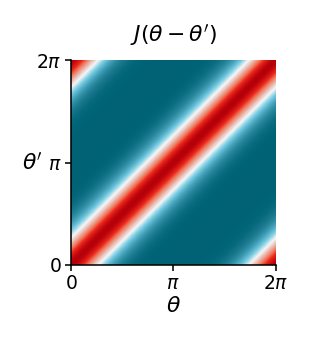

In [16]:
"""
Show connectivity example
"""

t = np.linspace(0, 2*np.pi, 1000)
dt = np.abs(t[:,None] - t[None,:])
dt = np.minimum(dt, 2*np.pi-dt)
J_sample = np.exp(-dt**2)
plt.imshow(J_sample, cmap=style.DIVERGING_CMAP, extent=[0, 2*np.pi, 0, 2*np.pi], origin='lower')
plt.xticks([0, np.pi, 2*np.pi], ['$0$', '$\\pi$', '$2\\pi$'])
plt.yticks([0, np.pi, 2*np.pi], ['$0$', '$\\pi$', '$2\\pi$'])
plt.gca().set_aspect(1.)
plt.title("$J(\\theta-\\theta')$")
plt.xlabel("$\\theta$")
plt.ylabel("$\\theta'$", rotation=0, va='center')



(0.0, 1.0)

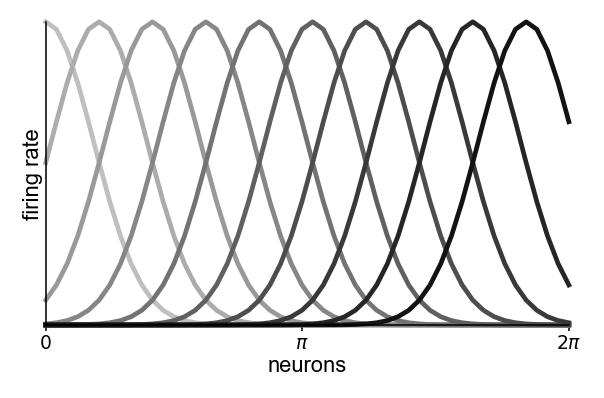

In [17]:
"""
Show tuning curve example
"""

plt.figure(figsize=(3., 1.75))
idx = np.arange(50)
for i in range(0, 50, 5):
    bump = np.exp(-(idx-i)**2 / 40)
    plt.plot(idx, bump, color=str(0.75*(1-i/50)), clip_on=False, lw=1.5)

plt.xticks([0, 24, 49], ['$0$', '$\\pi$', '$2\\pi$'])
plt.yticks([])
plt.ylabel("firing rate")
plt.xlabel("neurons")
plt.xlim(0, 49)
plt.ylim(0, 1)
    


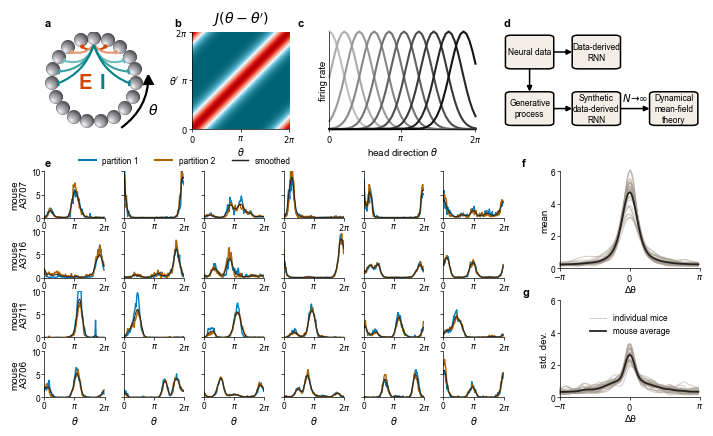

In [18]:
"""
Compose Fig. 1 in full: classical ring-attractor model vs mouse HD tuning curves.

Every panel is drawn and composed in code:
  a   ring-attractor connectivity schematic (ring.plot.plot_ring_schematic)
  b   circulant Mexican-hat weights         (ring.plot.plot_circulant_weights)
  c   translation-invariant tuning curves   (ring.plot.plot_circulant_tuning_curves)
  d   flow of the paper                     (ring.plot.plot_flow_schematic)
  e   per-mouse data tuning curves          (ring.plot.plot_data_tuning_curves)
  f,g mean / std profiles across mice       (ring.plot.plot_mean_std_profiles)
"""


# Muted CV-fold colours; passing them here keeps the figure faithful to the paper.
PUBLISHED_FOLD_COLORS = (style.PARTITION_A, style.PARTITION_B)

FIG_W = style.FULL_W
# Centred: L and 1-R are equal, so the axes block sits centred on the canvas.
# The two move together, so R - L (which sets avail_in below) is unchanged and no
# panel is resized.
L, R = 0.045, 0.955

# --- top band: placed explicitly, not via GridSpec ---------------------------
# GridSpec fits aspect-locked axes inside their cell, which silently gives the
# schematic panels different heights depending on cell width. Positioning them by
# hand makes the panels exactly equal in height by construction.
#
# The band reads ring schematic, weights, classical tuning curves, flow of the
# paper, so the three classical-model panels come first and the flow schematic
# closes the row.
#
# Gaps are per-pair rather than shared, since the four panels differ in how close
# their ink comes to their axes box. The ring|weights gap holds the weight
# panel's 0/pi/2pi tick labels and its theta' label; the weights|tuning gap holds
# the tuning panel's "firing rate" label and its panel letter, so it is the
# widest. The flow schematic needs the least room on its left, because its boxes
# occupy only the top-left and bottom-left corners there, so the tuning|flow gap
# is the tightest. Since the flow panel's width is the remainder, widening the
# gaps comes out of it, the panel with the most slack.
GAP_RING_WTS_IN, GAP_WTS_TC_IN, GAP_TC_FLOW_IN = 0.30, 0.40, 0.28
GAP_REF_IN = 0.28                     # gap the band height was first solved for
W_TC_REF_IN = 1.46                    # tuning panel's width in that solution

FLOW_ASPECT = 1.35                    # flow schematic
SOMA_R = 0.155                        # ring somata, nearly touching
RING_ASPECT = (2 * SOMA_R + 2 + 0.48) / (2 * (1 + SOMA_R))  # ring panel x/y span

avail_in = (R - L) * FIG_W

# Reference band height, from the original equal-gap solution. Everything the
# top row measures is expressed relative to it, so the gaps and the overall
# height can each be changed without the other silently moving a panel.
BAND_H_REF_IN = (avail_in - W_TC_REF_IN - 3 * GAP_REF_IN) / (FLOW_ASPECT + RING_ASPECT + 1.0)

# --- vertical layout: written in inches, FIG_H derived -----------------------
# Sizing the bands in inches means resizing the bottom band leaves the top band's
# absolute height untouched, rather than rescaling it through a shared FIG_H.
#
# The figure targets the standard tall double-column height (style.TALL_H) so it
# sits in a harmonious set with the other main figures. The three vertical
# constants below are set by font metrics rather than design, since they hold the
# panel letters, the x-axis labels of the weight and tuning panels, and the
# bottom row of theta labels. The top schematic band keeps its fixed
# proportions (so the aspect-locked ring and weight panels stay undistorted); the
# extra height goes entirely to the bottom data band, giving the tuning-curve
# grid and mean/std profiles more vertical room.
TARGET_H_IN = style.TALL_H + 0.65
TOP_BAND_SCALE = 0.815     # top-band scale from the previous height solution
TOP_MARGIN_IN = 0.241
VGAP_IN = 0.424        # bounded below by the x-axis labels of the weight/tuning panels
BOT_MARGIN_IN = 0.250  # just clearing the bottom theta labels

BAND_H_IN = BAND_H_REF_IN * TOP_BAND_SCALE
BOT_BAND_IN = TARGET_H_IN - (TOP_MARGIN_IN + BAND_H_IN + VGAP_IN + BOT_MARGIN_IN)

# Panel widths follow from the scaled band height. The ring and weight panels are
# aspect-locked, so shortening the band narrows them; the tuning panel keeps the
# width it was given when it sat directly above F and G, which after the reorder
# is simply a fixed width. The width that frees up goes to the flow schematic,
# which is why it is laid out three columns by two rows rather than the two by
# three of the original standalone version. Its left edge lands on the right edge of the
# tuning-curve grid below, so the top and bottom bands break at the same x.
w_ring_in, w_wts_in = BAND_H_IN * RING_ASPECT, BAND_H_IN
W_TC_IN = W_TC_REF_IN
w_flow_in = avail_in - (w_ring_in + w_wts_in + W_TC_IN) - (GAP_RING_WTS_IN + GAP_WTS_TC_IN + GAP_TC_FLOW_IN)

FIG_H = TOP_MARGIN_IN + BAND_H_IN + VGAP_IN + BOT_BAND_IN + BOT_MARGIN_IN
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)

BAND_TOP = 1.0 - TOP_MARGIN_IN / FIG_H
band_h = BAND_H_IN / FIG_H
band_bottom = BAND_TOP - band_h

w_ring, w_wts = w_ring_in / FIG_W, w_wts_in / FIG_W
w_tc, w_flow = W_TC_IN / FIG_W, w_flow_in / FIG_W
g_ring_wts = GAP_RING_WTS_IN / FIG_W
g_wts_tc = GAP_WTS_TC_IN / FIG_W
g_tc_flow = GAP_TC_FLOW_IN / FIG_W

x = L
ax_ring = fig.add_axes([x, band_bottom, w_ring, band_h]); x += w_ring + g_ring_wts
ax_wts = fig.add_axes([x, band_bottom, w_wts, band_h]); x += w_wts + g_wts_tc
ax_tc = fig.add_axes([x, band_bottom, w_tc, band_h]); x += w_tc + g_tc_flow
ax_flow = fig.add_axes([x, band_bottom, w_flow, band_h])

# The theta in the ring schematic is set to match the theta in the weight panel's
# J(theta-theta') title, so the two panels label the same variable at the same size.
J_FONTSIZE = 12 * 0.85

plot.plot_ring_schematic(ax_ring, label_fontsize=18 * 0.9 * 0.9, theta_fontsize=J_FONTSIZE)
plot.plot_circulant_weights(ax_wts, title_fontsize=J_FONTSIZE)
plot.plot_circulant_tuning_curves(ax_tc)
plot.plot_flow_schematic(ax_flow, fontsize=6.4 * 0.95)

# --- bottom band: data tuning curves + mean/std profiles --------------------
bot = fig.add_gridspec(4, 9, width_ratios=[1]*6 + [0.28] + [1]*2,
                       wspace=0.35, hspace=0.30,
                       left=L, right=R,
                       top=(BOT_MARGIN_IN + BOT_BAND_IN) / FIG_H,
                       bottom=BOT_MARGIN_IN / FIG_H)
curve_axes = np.empty((4, 6), dtype=object)
for i in range(4):
    for j in range(6):
        curve_axes[i, j] = fig.add_subplot(bot[i, j])
ax_F = fig.add_subplot(bot[0:2, 7:])
ax_G = fig.add_subplot(bot[2:4, 7:])

# F and G take their x-extent from the gridspec but are repositioned vertically.
# Spanning two grid rows each would leave them only the grid's own row gap, which
# is sized for bare tick labels; F carries tick labels AND a theta x-label, so its
# axis ran into G's topmost tick label. Splitting the band explicitly keeps F's top
# and G's bottom flush with the curve grid while giving the pair a gap that fits.
GAP_FG_IN = 0.32
_p, _grid = ax_F.get_position(), (curve_axes[3, 0].get_position().y0,
                                  curve_axes[0, 0].get_position().y1)
_gap = GAP_FG_IN / FIG_H
_h = (_grid[1] - _grid[0] - _gap) / 2
ax_F.set_position([_p.x0, _grid[0] + _h + _gap, _p.width, _h])
ax_G.set_position([_p.x0, _grid[0], _p.width, _h])

mouse_nums_to_plot = analysis.select_mice_by_cell_count(mouse_nums, 4)
mus, stds = analysis.compute_mean_and_std_profiles_for_all_mice(Phi_m_data, mouse_nums)

plot.plot_data_tuning_curves(curve_axes, mouse_nums_to_plot, mouse_nums,
                             mouse_names, plain_tcs, scalings, Phi_m_data,
                             fold_colors=PUBLISHED_FOLD_COLORS)

# Thicken only the legend's line samples, not the plotted curves, so the three
# fold colours stay legible at the size the swatches are actually printed.
# Shifted right of the axes' left edge so it clears panel letter E, which now sits
# on the figure margin in line with A.
leg = curve_axes[0, 0].legend(ncol=3, bbox_to_anchor=(0.45, 0.98), loc='lower left')
for h in getattr(leg, 'legend_handles', None) or leg.legendHandles:
    h.set_linewidth(h.get_linewidth() * 1.5)

plot.plot_mean_std_profiles(ax_F, ax_G, mus, stds)
ax_G.set_facecolor((0, 0, 0, 0))
ax_G.legend(loc='lower center', bbox_to_anchor=(0.5, 0.56))
# These two overrode plot_profile's own $\\Delta\\theta$ with $\\theta$, which is wrong:
# the curves are aligned on each neuron's centre of mass, so the abscissa is an
# angular difference. Fig. 5a,b plots the identical arrays and labels it
# $\\Delta\\theta$, so the two figures disagreed. Overrides removed.

# --- panel letters ----------------------------------------------------------
# Placed in figure coordinates rather than per-axes fractions. Axes fractions
# make every letter's offset mean a different physical distance, so panels of
# different widths never line up; figure coordinates let the left column (A, E)
# and the right column (F, G) each share one x, and the two bands each share one
# y. Each remaining top-band letter is offset from its own panel by just enough
# to clear that panel's left-hand labels, namely nothing for the flow schematic,
# the tick labels for the weight panel, and the "firing rate" label for the
# tuning panel.
LETTER_KW = dict(fontsize=8, fontweight='bold', va='bottom', ha='left')

pos_ring, pos_wts, pos_tc, pos_flow = (a.get_position()
                                       for a in (ax_ring, ax_wts, ax_tc, ax_flow))
pos_F, pos_G = ax_F.get_position(), ax_G.get_position()
top_of_grid = curve_axes[0, 0].get_position().y1

X_LEFT = pos_ring.x0                    # the band starts at the figure margin
X_RIGHT = pos_F.x0 - 0.052              # clears F/G's tick labels and y-labels
Y_TOP = pos_ring.y1 + 0.008
Y_BOT = top_of_grid + 0.008

fig.text(X_LEFT, Y_TOP, 'a', **LETTER_KW)
fig.text(pos_wts.x0 - 0.024, Y_TOP, 'b', **LETTER_KW)   # clears the 0/pi/2pi ticks
fig.text(pos_tc.x0 - 0.044, Y_TOP, 'c', **LETTER_KW)
fig.text(pos_flow.x0, Y_TOP, 'd', **LETTER_KW)          # boxes start at the axes edge
fig.text(X_LEFT, Y_BOT, 'e', **LETTER_KW)
fig.text(X_RIGHT, Y_BOT, 'f', **LETTER_KW)
fig.text(X_RIGHT, pos_G.y1 + 0.008, 'g', **LETTER_KW)

if SAVE_FIGURES:
    plt.savefig("../figures/classical_attractor_vs_data.pdf", dpi=400)